# PENTAKSIRAN BERTERUSAN AMALI 2: KV-TRON OBJECT DETECTION
* **Nama Calon:** [Muhammad Haikal Bin Zakaria]
* **Angka Giliran:** [PKV0125KA006]
* **Kursus:** DKA3223 - AI Untuk Computer Vision

---
### Pernyataan Hak Cipta & Etika
1. **Hak Cipta Data:** Etika penggunaan dataset visual industri dipatuhi mengikut piawaian perlindungan data (Data Protection Standards).
2. **Etika Pembangunan AI:** Komitmen penuh terhadap pembangunan model pengawasan visual yang bertanggungjawab (Responsible AI) bagi tujuan kawalan kualiti dan analisis pemantauan automatik.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 5.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
MAKLUMAT SISTEM
PyTorch       : 2.11.0+cu128
CUDA tersedia : True
Peranti YOLO  : 0
Nama GPU      : Tesla T4
Imej: /content/bus.jpg
Saiz: (810, 1080)


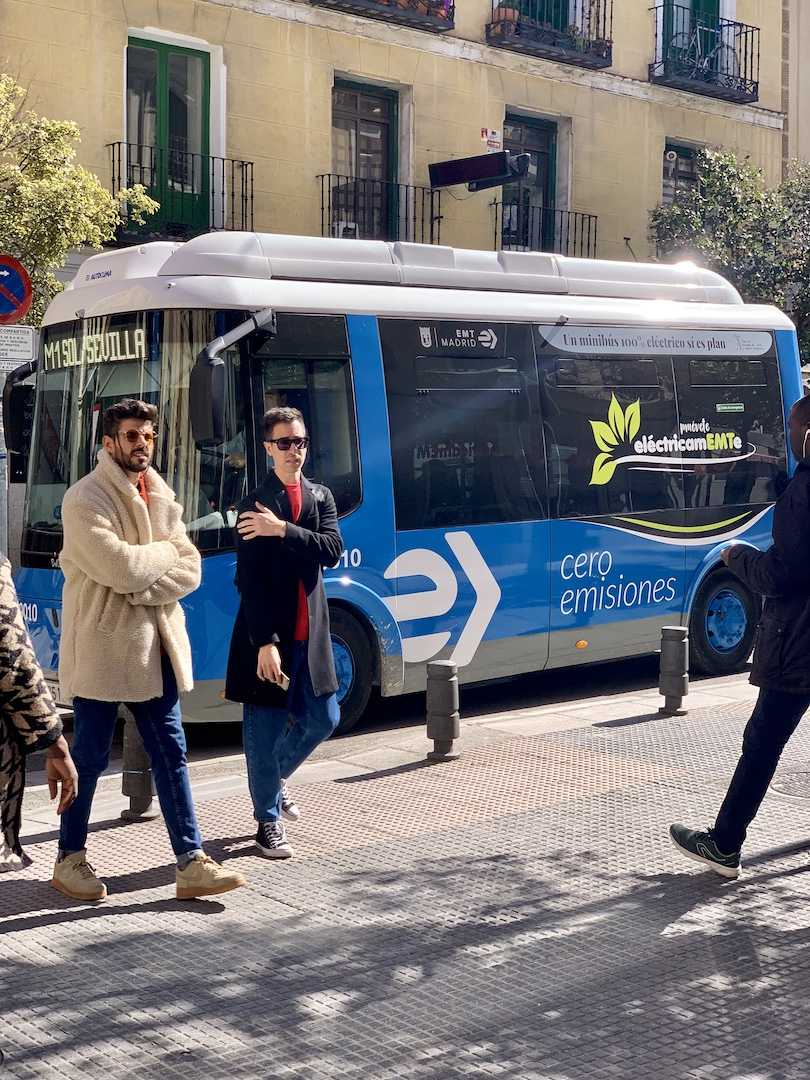

Model berjaya dimuatkan: yolo11n.pt
Jumlah kelas: 80
Confidence threshold: 0.25
IoU threshold       : 0.45
Jumlah objek        : 5


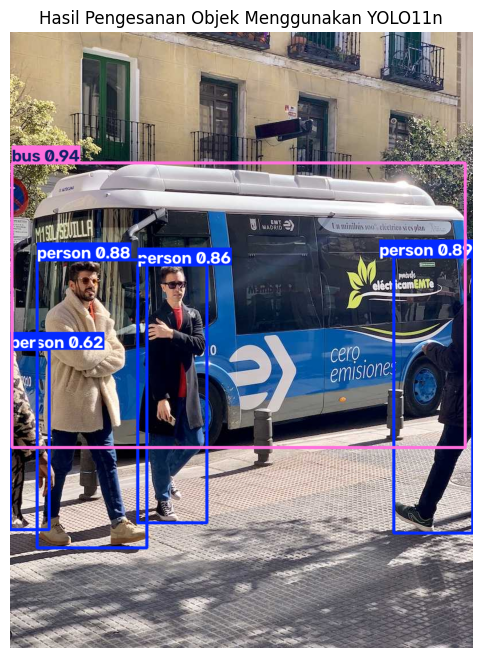

BUTIRAN PENGESANAN
01. bus          | keyakinan=94.02% | kotak=(3.8, 229.4, 796.2, 728.4)
02. person       | keyakinan=88.82% | kotak=(671.0, 394.8, 809.8, 878.7)
03. person       | keyakinan=87.83% | kotak=(47.4, 399.6, 239.3, 904.2)
04. person       | keyakinan=85.58% | kotak=(223.1, 408.7, 344.5, 860.4)
05. person       | keyakinan=62.19% | kotak=(0.0, 556.1, 68.9, 872.4)
Confidence 0.25 → 5 objek
Confidence 0.50 → 5 objek
Confidence 0.75 → 4 objek
Confidence 0.90 → 1 objek


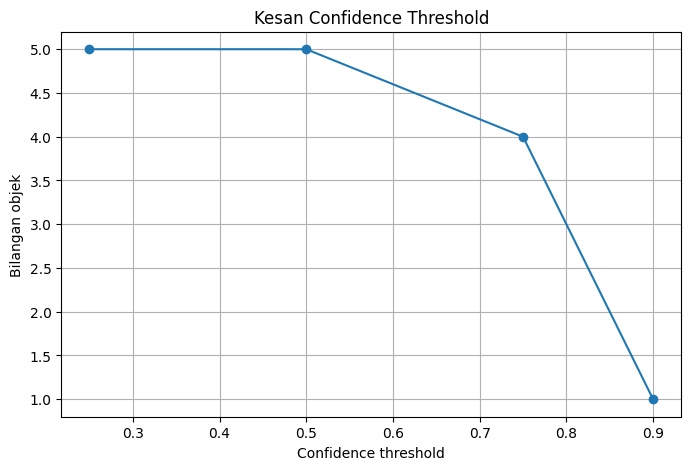

IoU 0.30 → 5 objek
IoU 0.45 → 5 objek
IoU 0.60 → 5 objek
IoU 0.75 → 5 objek
KIRAAN OBJEK MENGIKUT KELAS
person         : 4
bus            : 1

Jumlah keseluruhan: 5


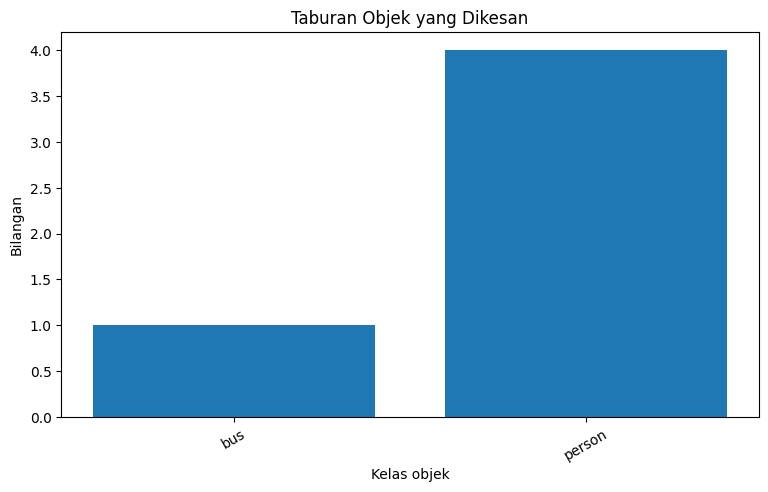

Video contoh tersedia: /content/vtest.avi
Frame diproses : 120
Video hasil disimpan di : /content/kv_tron_fixed.mp4


JUMLAH DETECTION SEPANJANG VIDEO
person         : 597
car            : 120
truck          : 120
dog            : 21
PENGESAHAN 5 FIX ME
✅ FIX ME 1 — CONF_THRESHOLD
✅ FIX ME 2 — IOU_THRESHOLD
✅ FIX ME 3 — CONF_VALUES
✅ FIX ME 4 — record["nama_kelas"]
✅ FIX ME 5 — MAX_FRAMES

PENGESAHAN MISI
✅ Tahap 1 — Sistem sedia
✅ Tahap 2 — Pengesanan imej
✅ Tahap 3 — Eksperimen threshold
✅ Tahap 4 — Kiraan objek
✅ Tahap 5 — Video berjaya

XP      : 100 / 100
TAHAP   : MASTER PENGESANAN KV-TRON
LENCANA : SISTEM SEDIA, PENGENDALI YOLO, PENGAWAL AMBANG, PENGIRA OBJEK, PENGANALISIS VIDEO

[LULUS] Tahniah! Semua lima FIX ME dan aktiviti Amali 2 selesai.


In [1]:
# ==============================================================================
# PENTAKSIRAN BERTERUSAN AMALI 2: KV-TRON OBJECT DETECTION
# KURSUS: DKA3223 - ARTIFICIAL INTELLIGENCE FOR COMPUTER VISION
# ==============================================================================

# Langkah 1 — Penyediaan Persekitaran & Semakan Peranti (GPU/CPU)
!pip install -q ultralytics

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter
from IPython.display import display, Video
from google.colab import files
from ultralytics import YOLO

# Tetapkan random seed untuk reproducibility (Arahan 5.2d)
torch.manual_seed(42)

# Semak ketersediaan GPU Accelerator
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("=" * 60)
print("MAKLUMAT SISTEM")
print("=" * 60)
print("PyTorch       :", torch.__version__)
print("CUDA tersedia :", torch.cuda.is_available())
print("Peranti YOLO  :", DEVICE)

if torch.cuda.is_available():
    print("Nama GPU      :", torch.cuda.get_device_name(0))


# Langkah 2 — Memuatkan Imej Input & Model YOLO11n
GUNA_IMEJ_SENDIRI = False

if GUNA_IMEJ_SENDIRI:
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("Tiada imej dimuat naik.")
    IMAGE_PATH = next(iter(uploaded.keys()))
else:
    IMAGE_PATH = "/content/bus.jpg"
    !wget -q -O "$IMAGE_PATH" "https://ultralytics.com/images/bus.jpg"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(f"Imej tidak ditemui: {IMAGE_PATH}")

image_rgb = Image.open(IMAGE_PATH).convert("RGB")
print("Imej:", IMAGE_PATH)
print("Saiz:", image_rgb.size)
display(image_rgb)

# Memuatkan senibina model YOLO11n
MODEL_NAME = "yolo11n.pt"
model = YOLO(MODEL_NAME)

print("Model berjaya dimuatkan:", MODEL_NAME)
print("Jumlah kelas:", len(model.names))


# Langkah 3 — Pelaksanaan Inferens & Ekstraksi Bounding Box
# ============================================================
# FIX ME 1 — CONF_THRESHOLD (DISELESAIKAN)
# ============================================================
CONF_THRESHOLD = 0.25

if CONF_THRESHOLD is None:
    raise ValueError("FIX ME 1 belum lengkap. Tetapkan CONF_THRESHOLD, contoh: 0.25")
if not isinstance(CONF_THRESHOLD, (int, float)):
    raise TypeError("CONF_THRESHOLD mestilah nombor.")
if not 0 < CONF_THRESHOLD <= 1:
    raise ValueError("CONF_THRESHOLD mestilah antara 0 dan 1.")

# ============================================================
# FIX ME 2 — IOU_THRESHOLD (DISELESAIKAN)
# ============================================================
IOU_THRESHOLD = 0.45

if IOU_THRESHOLD is None:
    raise ValueError("FIX ME 2 belum lengkap. Tetapkan IOU_THRESHOLD, contoh: 0.45")
if not isinstance(IOU_THRESHOLD, (int, float)):
    raise TypeError("IOU_THRESHOLD mestilah nombor.")
if not 0 < IOU_THRESHOLD <= 1:
    raise ValueError("IOU_THRESHOLD mestilah antara 0 dan 1.")

# Jalankan inferens
results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    device=DEVICE,
    verbose=False
)

result = results[0]

print("Confidence threshold:", CONF_THRESHOLD)
print("IoU threshold       :", IOU_THRESHOLD)
print("Jumlah objek        :", len(result.boxes))

# Paparkan hasil visualisasi
annotated_bgr = result.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Hasil Pengesanan Objek Menggunakan YOLO11n")
plt.show()

# Ekstrak Maklumat Pengesanan
detection_records = []

print("=" * 95)
print("BUTIRAN PENGESANAN")
print("=" * 95)

for i, box in enumerate(result.boxes, start=1):
    class_id = int(box.cls[0].item())
    class_name = model.names[class_id]
    confidence = float(box.conf[0].item())
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    record = {
        "nombor": i,
        "id_kelas": class_id,
        "nama_kelas": class_name,
        "keyakinan": confidence,
        "bounding_box": [x1, y1, x2, y2],
    }
    detection_records.append(record)

    print(
        f"{i:02d}. {class_name:<12} | "
        f"keyakinan={confidence:.2%} | "
        f"kotak=({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})"
    )

if not detection_records:
    print("Tiada objek dikesan. Cuba gunakan nilai confidence yang lebih rendah.")


# Langkah 4 — Eksperimen Ambang Keyakinan (Confidence Threshold) & IoU
# ============================================================
# FIX ME 3 — CONF_VALUES (DISELESAIKAN)
# ============================================================
CONF_VALUES = [0.25, 0.50, 0.75, 0.90]

if CONF_VALUES is None:
    raise ValueError("FIX ME 3 belum lengkap. Tetapkan CONF_VALUES.")
if not isinstance(CONF_VALUES, list) or len(CONF_VALUES) != 4:
    raise ValueError("CONF_VALUES mestilah senarai yang mengandungi empat nilai.")
if not all(isinstance(value, (int, float)) for value in CONF_VALUES):
    raise TypeError("Semua nilai dalam CONF_VALUES mestilah nombor.")
if not all(0 < value <= 1 for value in CONF_VALUES):
    raise ValueError("Semua nilai CONF_VALUES mestilah antara 0 dan 1.")

conf_summary = []

for conf_value in CONF_VALUES:
    test_result = model.predict(
        source=IMAGE_PATH,
        conf=conf_value,
        iou=IOU_THRESHOLD,
        device=DEVICE,
        verbose=False
    )[0]

    total = len(test_result.boxes)
    conf_summary.append((conf_value, total))
    print(f"Confidence {conf_value:.2f} → {total} objek")

# Plot graf analisa Confidence
x_conf = [item[0] for item in conf_summary]
y_conf = [item[1] for item in conf_summary]

plt.figure(figsize=(8, 5))
plt.plot(x_conf, y_conf, marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("Bilangan objek")
plt.title("Kesan Confidence Threshold")
plt.grid(True)
plt.show()

# Eksperimen IoU Threshold
IOU_VALUES = [0.30, 0.45, 0.60, 0.75]
iou_summary = []

for iou_value in IOU_VALUES:
    test_result = model.predict(
        source=IMAGE_PATH,
        conf=CONF_THRESHOLD,
        iou=iou_value,
        device=DEVICE,
        verbose=False
    )[0]

    total = len(test_result.boxes)
    iou_summary.append((iou_value, total))
    print(f"IoU {iou_value:.2f} → {total} objek")


# Langkah 5 — Analisis Pengiraan Objek Automatik
# ============================================================
# FIX ME 4 — OBJECT COUNTING (DISELESAIKAN)
# ============================================================
OBJECT_CLASS_FIELD = "nama_kelas"

if OBJECT_CLASS_FIELD is None:
    raise ValueError('FIX ME 4 belum lengkap. Gunakan OBJECT_CLASS_FIELD = "nama_kelas"')
if OBJECT_CLASS_FIELD not in {"nama_kelas"}:
    raise ValueError('Medan yang betul ialah "nama_kelas".')

object_counter = Counter(
    record[OBJECT_CLASS_FIELD] for record in detection_records
)

print("=" * 45)
print("KIRAAN OBJEK MENGIKUT KELAS")
print("=" * 45)

if object_counter:
    for class_name, count in object_counter.most_common():
        print(f"{class_name:<15}: {count}")
else:
    print("Tiada objek untuk dikira.")

print("\nJumlah keseluruhan:", sum(object_counter.values()))

# Visualisasi Bar Chart
if object_counter:
    labels = list(object_counter.keys())
    counts = list(object_counter.values())

    plt.figure(figsize=(9, 5))
    plt.bar(labels, counts)
    plt.xlabel("Kelas objek")
    plt.ylabel("Bilangan")
    plt.title("Taburan Objek yang Dikesan")
    plt.xticks(rotation=30)
    plt.show()


# Langkah 6 — Pengesanan Objek pada Video (Pemprosesan Inferens Video Real-Time)
VIDEO_PATH = "/content/vtest.avi"
OUTPUT_VIDEO_PATH = "/content/kv_tron_detection_output.mp4"
FIXED_VIDEO_PATH = "/content/kv_tron_fixed.mp4"

# Muat turun vtest.avi jika tidak ditemui secara tempatan
if not os.path.exists(VIDEO_PATH):
    !wget -q -O "$VIDEO_PATH" "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi"

if not os.path.exists(VIDEO_PATH):
    raise FileNotFoundError("Video contoh gagal dimuat turun.")

print("Video contoh tersedia:", VIDEO_PATH)

# ============================================================
# FIX ME 5 — MAX_FRAMES (DISELESAIKAN)
# ============================================================
MAX_FRAMES = 120

if MAX_FRAMES is None:
    raise ValueError("FIX ME 5 belum lengkap. Tetapkan MAX_FRAMES, contoh: 120")
if not isinstance(MAX_FRAMES, int) or MAX_FRAMES <= 0:
    raise ValueError("MAX_FRAMES mestilah nombor bulat lebih besar daripada 0.")

VIDEO_CONF = 0.30
VIDEO_IOU = 0.45

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError("Video tidak dapat dibuka.")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

if fps <= 0:
    fps = 25.0

writer = cv2.VideoWriter(
    OUTPUT_VIDEO_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

frame_count = 0
video_object_counter = Counter()

while cap.isOpened() and frame_count < MAX_FRAMES:
    success, frame = cap.read()
    if not success:
        break

    frame_result = model.predict(
        source=frame,
        conf=VIDEO_CONF,
        iou=VIDEO_IOU,
        device=DEVICE,
        verbose=False
    )[0]

    for box in frame_result.boxes:
        class_id = int(box.cls[0].item())
        class_name = model.names[class_id]
        video_object_counter[class_name] += 1

    annotated_frame = frame_result.plot()
    writer.write(annotated_frame)
    frame_count += 1

cap.release()
writer.release()

print("Frame diproses :", frame_count)

# Penukaran Codec Video untuk Menyokong Pemutaran Web Browser di Colab
os.system(f"ffmpeg -y -i {OUTPUT_VIDEO_PATH} -vcodec libx264 {FIXED_VIDEO_PATH} -loglevel quiet")

print("Video hasil disimpan di :", FIXED_VIDEO_PATH)

# Paparkan Video Output secara langsung
display(Video(FIXED_VIDEO_PATH, embed=True, width=600))

print("=" * 50)
print("JUMLAH DETECTION SEPANJANG VIDEO")
print("=" * 50)

for class_name, count in video_object_counter.most_common(10):
    print(f"{class_name:<15}: {count}")


# Langkah 7 — Pengesahan Automatik Gamifikasi (FIX ME)
fix_me_checks = {
    "FIX ME 1 — CONF_THRESHOLD": (
        isinstance(CONF_THRESHOLD, (int, float))
        and 0 < CONF_THRESHOLD <= 1
    ),
    "FIX ME 2 — IOU_THRESHOLD": (
        isinstance(IOU_THRESHOLD, (int, float))
        and 0 < IOU_THRESHOLD <= 1
    ),
    "FIX ME 3 — CONF_VALUES": (
        isinstance(CONF_VALUES, list)
        and len(CONF_VALUES) == 4
        and all(isinstance(value, (int, float)) for value in CONF_VALUES)
        and all(0 < value <= 1 for value in CONF_VALUES)
    ),
    'FIX ME 4 — record["nama_kelas"]': (
        OBJECT_CLASS_FIELD == "nama_kelas"
    ),
    "FIX ME 5 — MAX_FRAMES": (
        isinstance(MAX_FRAMES, int)
        and MAX_FRAMES > 0
    ),
}

checks = {
    "Tahap 1 — Sistem sedia": model is not None,
    "Tahap 2 — Pengesanan imej": len(detection_records) > 0,
    "Tahap 3 — Eksperimen threshold": (
        len(conf_summary) == len(CONF_VALUES)
        and len(iou_summary) == 4
    ),
    "Tahap 4 — Kiraan objek": sum(object_counter.values()) > 0,
    "Tahap 5 — Video berjaya": (
        os.path.exists(OUTPUT_VIDEO_PATH)
        and frame_count > 0
        and frame_count <= MAX_FRAMES
    ),
}

xp = 0
badges = []

if checks["Tahap 1 — Sistem sedia"]:
    xp += 10
    badges.append("SISTEM SEDIA")

if checks["Tahap 2 — Pengesanan imej"]:
    xp += 20
    badges.append("PENGENDALI YOLO")

if checks["Tahap 3 — Eksperimen threshold"]:
    xp += 20
    badges.append("PENGAWAL AMBANG")

if checks["Tahap 4 — Kiraan objek"]:
    xp += 20
    badges.append("PENGIRA OBJEK")

if checks["Tahap 5 — Video berjaya"]:
    xp += 30
    badges.append("PENGANALISIS VIDEO")

if xp >= 90:
    rank = "MASTER PENGESANAN KV-TRON"
elif xp >= 70:
    rank = "JURUTERA PENGESANAN"
elif xp >= 40:
    rank = "PENEROKA YOLO"
else:
    rank = "PELATIH VISI"

print("=" * 65)
print("PENGESAHAN 5 FIX ME")
print("=" * 65)

for name, passed in fix_me_checks.items():
    print(("✅" if passed else "❌"), name)

print("\n" + "=" * 65)
print("PENGESAHAN MISI")
print("=" * 65)

for name, passed in checks.items():
    print(("✅" if passed else "❌"), name)

print("\nXP      :", xp, "/ 100")
print("TAHAP   :", rank)
print("LENCANA :", ", ".join(badges) if badges else "Belum ada")

if all(fix_me_checks.values()) and all(checks.values()):
    print("\n[LULUS] Tahniah! Semua lima FIX ME dan aktiviti Amali 2 selesai.")
else:
    print("\n[BELUM SELESAI] Semak bahagian yang bertanda ❌.")